# Part B — Counterfactual Inflation Analysis: Ukraine in the Euro Area

**Baseline model:** Ciccarelli & Mojon (2010) — common factor extracted from EA inflation panel (PCA), Ukraine's loading estimated on quiet periods (peg + stable IT), counterfactual = EA factor path projected through that loading.

$$\hat{\pi}^{CF}_{UKR,t} = \hat{\alpha}_{quiet} + \hat{\lambda}_{quiet} \cdot \hat{F}^{EA}_t$$

Limitations of this baseline and the move to SVAR are documented in Section 7.

In [25]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd = Path.cwd()
DATA_PROCESSED = cwd.parent / "data" / "data_processed"
OUTPUTS = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

## 1. Data loading

In [26]:
df = pd.read_csv(
    DATA_PROCESSED / "inflation_panel.csv",
    parse_dates=["date"],
    index_col="date"
)

print(f"Shape: {df.shape} | {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.describe().T[["mean", "std", "min", "max"]].round(2)

Shape: (240, 12) | 2006-01-01 → 2025-12-01
Missing values: 0


,mean,std,min,max
AT,2.68,2.19,-0.4,11.60
BE,2.53,2.37,-1.7,13.10
DE,2.22,2.13,-0.7,11.60
ES,2.14,2.22,-1.5,10.70
FI,2.01,1.81,-0.7,9.10
FR,1.85,1.65,-0.8,7.30
GR,1.93,2.71,-2.9,12.10
IE,1.48,2.38,-2.9,9.60
IT,2.02,2.34,-1.0,12.60
NL,2.37,2.63,-1.0,17.10


## 2. Descriptive visualisation

Regime shading from Part A chronology.

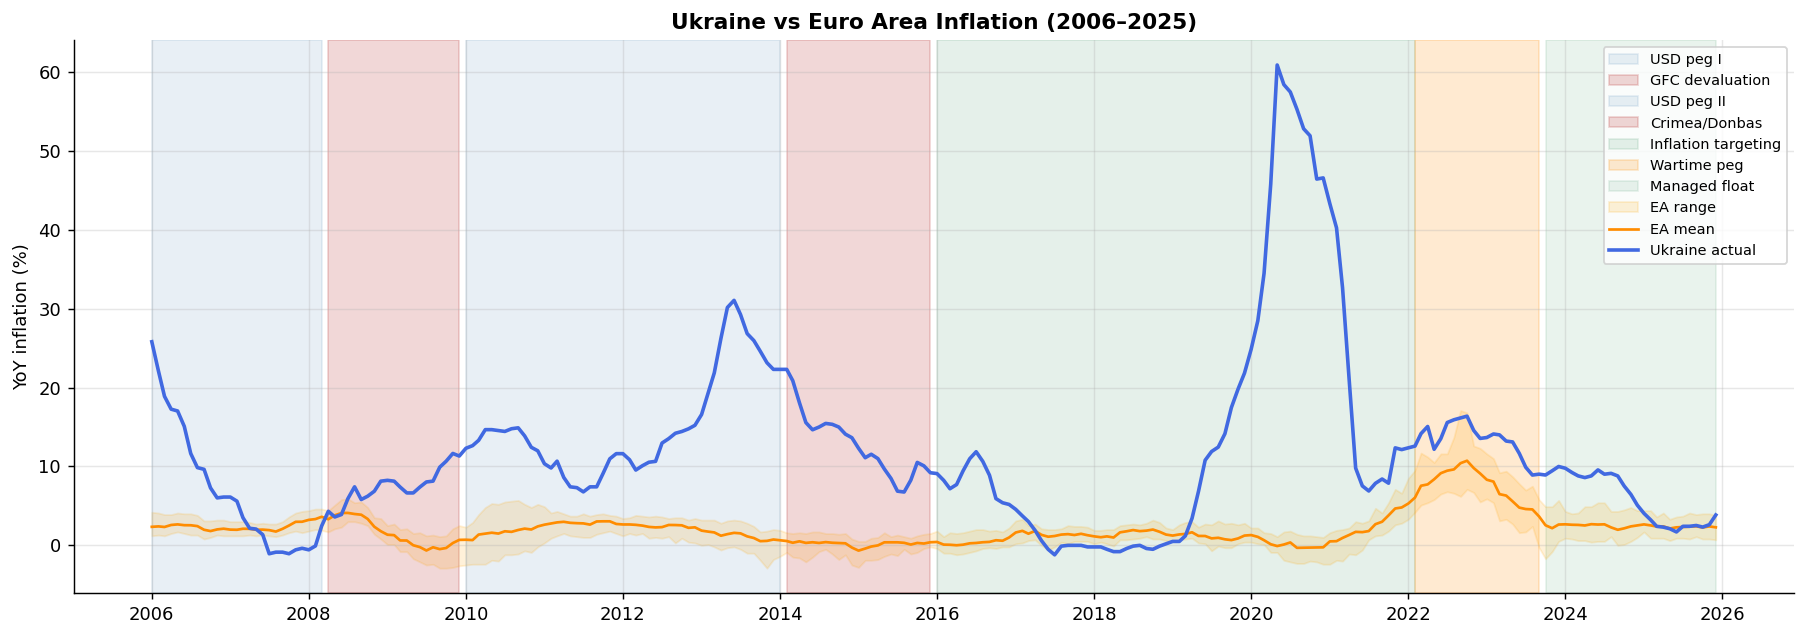

In [27]:
REGIMES = [
    ("2006-01", "2008-03", "USD peg I",             "steelblue",  0.12),
    ("2008-04", "2009-12", "GFC devaluation",        "firebrick",  0.18),
    ("2010-01", "2014-01", "USD peg II",             "steelblue",  0.12),
    ("2014-02", "2015-12", "Crimea/Donbas",          "firebrick",  0.18),
    ("2016-01", "2022-02", "Inflation targeting",    "seagreen",   0.12),
    ("2022-02", "2023-09", "Wartime peg",            "darkorange", 0.18),
    ("2023-10", "2025-12", "Managed float",          "seagreen",   0.10),
]

EA_COUNTRIES = [c for c in df.columns if c != "UKR"]
ea_mean = df[EA_COUNTRIES].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))

for start, end, label, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha, label=label)

ax.fill_between(df.index, df[EA_COUNTRIES].min(axis=1), df[EA_COUNTRIES].max(axis=1),
                color="orange", alpha=0.15, label="EA range")
ax.plot(df.index, ea_mean, color="darkorange", lw=1.5, label="EA mean")
ax.plot(df.index, df["UKR"], color="royalblue", lw=2, label="Ukraine actual")

handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
ax.legend(*zip(*unique), fontsize=8, loc="upper right")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_ylabel("YoY inflation (%)")
ax.set_title("Ukraine vs Euro Area Inflation (2006–2025)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "fig1_raw_series.png", dpi=150)
plt.show()

## 3. Stationarity tests

ADF (H0: unit root) and KPSS (H0: stationary). Required before OLS and SVAR estimation.

In [28]:
results = []
for col in df.columns:
    s = df[col].dropna()
    adf_p  = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="ct", nlags="auto")[1]
    results.append({
        "Country": col,
        "ADF p-val": round(adf_p, 3),
        "ADF reject H0": "Yes" if adf_p < 0.05 else "No",
        "KPSS p-val": round(kpss_p, 3),
        "KPSS reject H0": "Yes" if kpss_p < 0.05 else "No",
        "Verdict": "Stationary" if (adf_p < 0.05 and kpss_p >= 0.05) else "Ambiguous"
    })

pd.DataFrame(results).set_index("Country")

,ADF p-val,ADF reject H0,KPSS p-val,KPSS reject H0,Verdict
Country,,,,,
AT,0.119,No,0.043,Yes,Ambiguous
BE,0.118,No,0.075,No,Ambiguous
DE,0.043,Yes,0.045,Yes,Ambiguous
ES,0.175,No,0.010,Yes,Ambiguous
FI,0.070,No,0.067,No,Ambiguous
FR,0.243,No,0.035,Yes,Ambiguous
GR,0.250,No,0.010,Yes,Ambiguous
IE,0.078,No,0.024,Yes,Ambiguous
IT,0.102,No,0.053,No,Ambiguous


## 4. Euro Area common factor (PCA)

Ukraine excluded from PCA — we do not want its idiosyncratic dynamics to contaminate the EA factor.

PC1 explains 84.7% of EA inflation variance
PC1 explains 84.7% of EA inflation variance


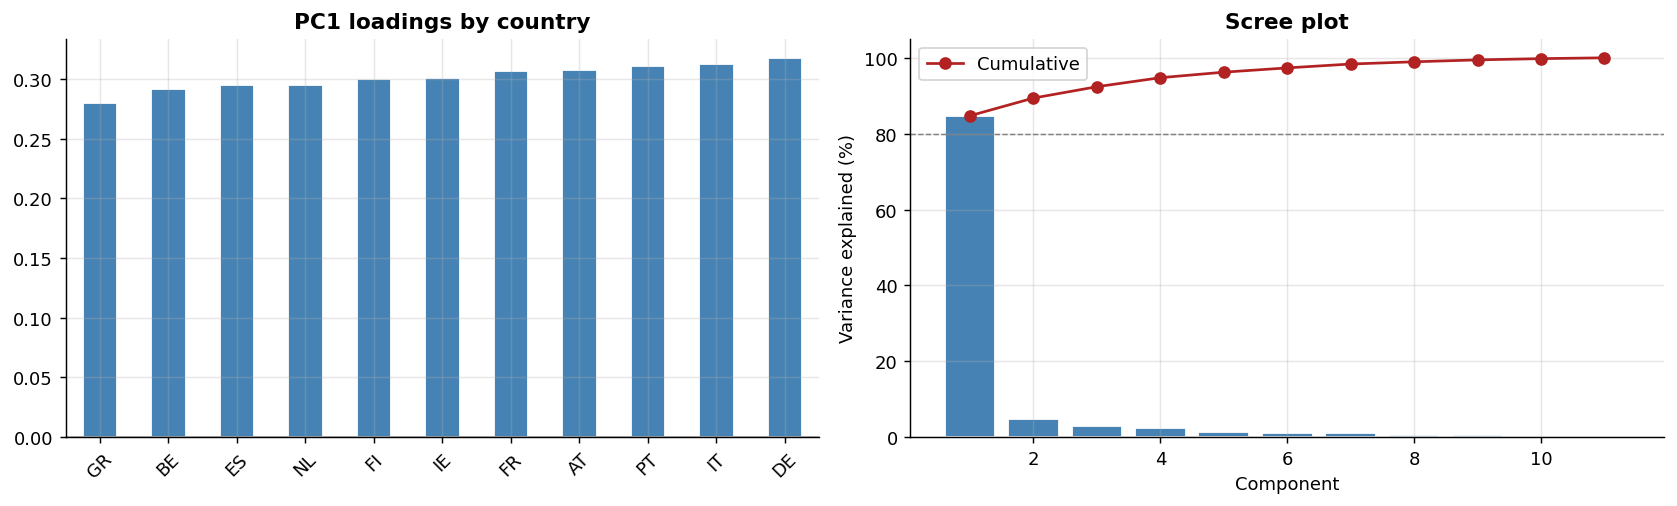

In [29]:
euro_df = df[EA_COUNTRIES].copy()

scaler = StandardScaler()
euro_scaled = scaler.fit_transform(euro_df)

pca = PCA(n_components=len(EA_COUNTRIES))
pca.fit(euro_scaled)
explained = pca.explained_variance_ratio_

factor = ea_mean.rename("EURO_FACTOR")

# Le signe du facteur PCA est arbitraire.
# On s'assure qu'il est positivement corrélé avec la moyenne EA.
if np.corrcoef(factor, ea_mean.loc[factor.index])[0, 1] < 0:
    factor = -factor

print(f"PC1 explains {explained[0]:.1%} of EA inflation variance")
print(f"PC1 explains {explained[0]:.1%} of EA inflation variance")

# Scree + loadings
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.Series(pca.components_[0], index=EA_COUNTRIES).sort_values().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("PC1 loadings by country", fontweight="bold")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(range(1, len(explained)+1), explained*100, color="steelblue", edgecolor="white")
axes[1].plot(range(1, len(explained)+1), np.cumsum(explained)*100, "o-", color="firebrick",
             label="Cumulative")
axes[1].axhline(80, color="gray", ls="--", lw=0.8)
axes[1].set_title("Scree plot", fontweight="bold")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Variance explained (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "fig2_pca_diagnostics.png", dpi=150)
plt.show()

## 5. OLS estimation

Two specifications:
- **Full sample**: biased downward because crisis episodes pull λ toward zero
- **Quiet periods** (peg I, peg II, stable IT 2017-21): used for the counterfactual — captures how Ukraine co-moves with EA when externally anchored, which is precisely what EA membership would impose

In [35]:
data["counterfactual"] = ea_mean.loc[data.index]
data["gap"] = data["UKR"] - data["counterfactual"]

In [34]:
if np.corrcoef(factor.values, ea_mean.loc[factor.index].values)[0, 1] < 0:
    factor = -factor

print("Corrélation facteur/ea_mean :", np.corrcoef(factor.values, ea_mean.loc[factor.index].values)[0, 1])
print("Signe du facteur (mean) :", factor.mean())

data = df[["UKR"]].join(factor, how="inner").dropna()

# Full-sample OLS
model_full = sm.OLS(
    data["UKR"],
    sm.add_constant(data["EURO_FACTOR"])
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# Quiet-period OLS
quiet_mask = (
    ((data.index >= "2006-01") & (data.index <= "2008-03")) |   # USD peg I
    ((data.index >= "2010-01") & (data.index <= "2013-12")) |   # USD peg II
    ((data.index >= "2017-01") & (data.index <= "2021-12"))     # stable IT
)
data_quiet = data[quiet_mask]

model_quiet = sm.OLS(
    data_quiet["UKR"],
    sm.add_constant(data_quiet["EURO_FACTOR"])
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

lambda_quiet = model_quiet.params["EURO_FACTOR"]
alpha_quiet  = model_quiet.params["const"]

print("--- Full sample ---")
print(f"  α = {model_full.params['const']:.3f}  λ = {model_full.params['EURO_FACTOR']:.3f}  R² = {model_full.rsquared:.3f}")
print()
print("--- Quiet periods ---")
print(f"  α = {alpha_quiet:.3f}  λ = {lambda_quiet:.3f}  R² = {model_quiet.rsquared:.3f}  N = {len(data_quiet)}")
print()
print(model_quiet.summary())

Corrélation facteur/ea_mean : 1.0
Signe du facteur (mean) : 2.1040151515151515
--- Full sample ---
  α = 13.487  λ = -0.824  R² = 0.023

--- Quiet periods ---
  α = 28.096  λ = -8.260  R² = 0.297  N = 135

                            OLS Regression Results                            
Dep. Variable:                    UKR   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     4.736
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0313
Time:                        21:53:02   Log-Likelihood:                -525.66
No. Observations:                 135   AIC:                             1055.
Df Residuals:                     133   BIC:                             1061.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
    

## 6. Counterfactual construction and main figure

In [31]:
data["counterfactual"] = model_quiet.predict(sm.add_constant(data["EURO_FACTOR"]))
data["gap"] = data["UKR"] - data["counterfactual"]

# Period-by-period summary
episodes = [
    ("2006-01", "2008-03", "USD peg I"),
    ("2008-04", "2009-12", "GFC 2008-09"),
    ("2010-01", "2014-01", "USD peg II"),
    ("2014-02", "2015-12", "Crimea/Donbas"),
    ("2016-01", "2022-02", "Inflation targeting"),
    ("2022-02", "2023-09", "Wartime"),
]
print(f"{'Period':<25} {'Actual':>8} {'CF':>8} {'Gap':>8}")
print("-" * 52)
for s, e, label in episodes:
    m = (data.index >= s) & (data.index <= e)
    if m.sum():
        a = data.loc[m, "UKR"].mean()
        c = data.loc[m, "counterfactual"].mean()
        print(f"{label:<25} {a:>7.1f}%  {c:>7.1f}%  {a-c:>+7.1f}pp")

Period                      Actual       CF      Gap
----------------------------------------------------
USD peg I                     6.8%     10.6%     -3.8pp
GFC 2008-09                   7.4%     15.6%     -8.1pp
USD peg II                   15.1%     13.0%     +2.1pp
Crimea/Donbas                12.9%     24.4%    -11.5pp
Inflation targeting          13.9%     17.6%     -3.7pp
Wartime                      13.4%    -21.8%    +35.1pp


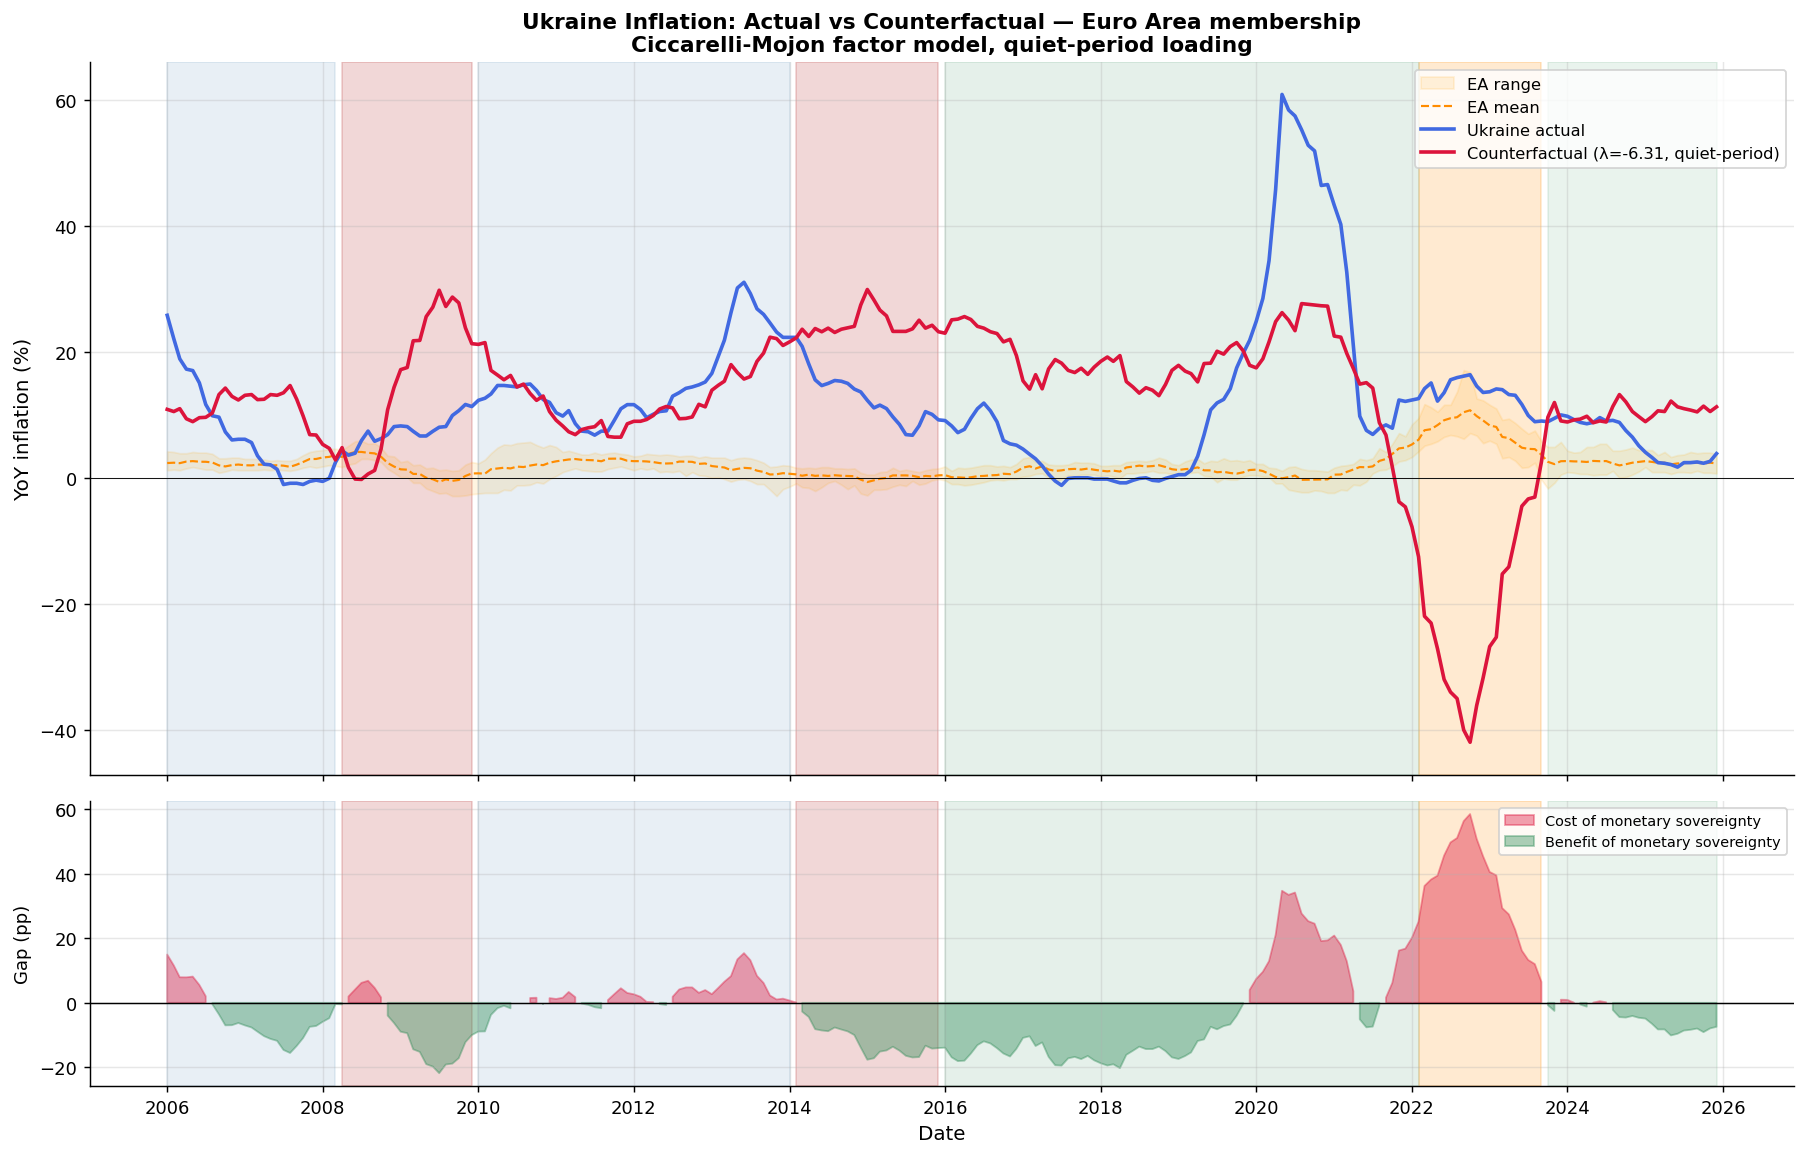

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2.5, 1]})
ax, ax2 = axes

for start, end, _, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)

ax.fill_between(df.index, df[EA_COUNTRIES].min(axis=1), df[EA_COUNTRIES].max(axis=1),
                color="orange", alpha=0.12, label="EA range")
ax.plot(df.index, ea_mean, color="darkorange", lw=1.2, ls="--", label="EA mean")
ax.plot(data.index, data["UKR"], color="royalblue", lw=2, label="Ukraine actual")
ax.plot(data.index, data["counterfactual"], color="crimson", lw=2,
        label=f"Counterfactual (λ={lambda_quiet:.2f}, quiet-period)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("YoY inflation (%)", fontsize=11)
ax.set_title("Ukraine Inflation: Actual vs Counterfactual — Euro Area membership\n"
             "Ciccarelli-Mojon factor model, quiet-period loading",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")

ax2.fill_between(data.index, data["gap"], 0,
                 where=data["gap"] > 0, color="crimson", alpha=0.4,
                 label="Cost of monetary sovereignty")
ax2.fill_between(data.index, data["gap"], 0,
                 where=data["gap"] < 0, color="seagreen", alpha=0.4,
                 label="Benefit of monetary sovereignty")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Gap (pp)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=8, loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUTS / "fig3_counterfactual_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Limitations and roadmap to SVAR

This baseline is a necessary first step but has three structural limits:

**No supply/demand decomposition.** Under EA membership, Ukraine's demand shocks would have been replaced by ECB policy — but its supply shocks (energy, agriculture, geopolitics) would have remained. OLS treats all shocks the same. The SVAR with Blanchard-Quah identification (permanent = supply, transitory = demand) separates them explicitly.

**Constant treatment intensity.** The quiet-period λ is constant across all periods. But from Part A, the treatment effect of EA membership is near-zero during peg periods (Ukraine already had no monetary policy) and large during 2014-15 and 2022 (when devaluation was the main adjustment mechanism). The SVAR will allow period-specific treatment weights.

**No dynamics.** OLS gives a static mapping. Local projections (Jordà, 2005) will show how long the counterfactual gap would have persisted after each structural shock — which matters for assessing the medium-term costs of monetary sovereignty.

**→ The SVAR notebook sources external data (industrial production UA and EA, exchange rate, policy rates) and implements Blanchard-Quah identification.**

In [33]:
data[["UKR", "EURO_FACTOR", "counterfactual", "gap"]].to_csv(
    DATA_PROCESSED / "baseline_counterfactual.csv"
)

with open(DATA_PROCESSED / "baseline_params.json", "w") as f:
    json.dump({
        "alpha_quiet": float(alpha_quiet),
        "lambda_quiet": float(lambda_quiet),
        "r2_quiet": float(model_quiet.rsquared),
        "r2_full": float(model_full.rsquared),
        "n_quiet": int(len(data_quiet)),
        "n_full": int(len(data)),
    }, f, indent=2)

print("Saved: baseline_counterfactual.csv and baseline_params.json")

Saved: baseline_counterfactual.csv and baseline_params.json
